# Laboratorio: Redes Neuronales con PyTorch aplicadas al dataset Housing

## Objetivo
El objetivo del presente laboratorio es reutilizar la estructura del cuadernillo base desarrollado en clase, adaptándolo a un dataset real (`housing.csv`), con el fin de construir, entrenar y evaluar un modelo de red neuronal para la predicción de precios de viviendas.

## Tipo de problema
Se trata de un problema de regresión, donde se desea estimar el valor continuo de la variable `median_house_value`.

## Enfoque
Se reutiliza la lógica del cuadernillo del ingeniero (modelo, entrenamiento, optimización) y se adapta a:
- Preprocesamiento de datos reales
- Manejo de variables categóricas
- Escalado de datos
- Evaluación con métricas de regresión

IMPORTACIÓN DE LIBRERÍAS

In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CONFIGURACIÓN INICIAL

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

Dispositivo: cpu


CARGA Y ANÁLISIS DEL DATASET

In [3]:
df = pd.read_csv("housing.csv")

print("Dimensiones:", df.shape)
print(df.head())
print(df.dtypes)
print(df.isna().sum())

Dimensiones: (20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
longitude             float64
latitude            

# DEFINICIÓN DE VARIABLES
Se define median_house_value como variable dependiente, ya que representa el valor que el modelo debe predecir.
Las demás columnas funcionan como atributos de entrada del modelo.

In [4]:
# 4. DEFINICIÓN DE X E y
target_col = "median_house_value"

X = df.drop(columns=[target_col])
y = df[target_col]

# IDENTIFICACIÓN DE TIPOS DE VARIABLES
La diferenciación entre variables numéricas y categóricas permite aplicar transformaciones adecuadas a cada grupo.
Esto es indispensable porque una red neuronal espera entradas numéricas consistentes.

In [5]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

Numéricas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categóricas: ['ocean_proximity']


# PREPROCESAMIENTO
Se define un pipeline de transformación para asegurar que el dataset quede limpio, numéricamente estable y apto para el entrenamiento.
Las columnas numéricas son imputadas y escaladas; las categóricas son imputadas y codificadas en variables binarias.

In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# DIVISIÓN DE DATOS
Los datos se dividen en entrenamiento y prueba para evaluar la capacidad de generalización del modelo.
El preprocesador se ajusta únicamente con el conjunto de entrenamiento, evitando fuga de información hacia el conjunto de prueba.

In [7]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train = preprocessor.fit_transform(X_train_df)
X_test = preprocessor.transform(X_test_df)

if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
    X_test = X_test.toarray()

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (16512, 13)
Test: (4128, 13)


# CONVERSIÓN A TENSORES
En esta fase se convierten los arreglos procesados a tensores, que son la estructura nativa utilizada por PyTorch.
La variable objetivo se reestructura a una forma de columna (n,1) porque se trata de una salida única de regresión.

In [8]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
y_test_t = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

input_dim = X_train_t.shape[1]
print("Features finales:", input_dim)

Features finales: 13


MODELO (REUTILIZANDO EL DEL INGENIERO)

In [9]:

#  MODELO SEQUENTIAL

model_seq = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

print(model_seq)

Sequential(
  (0): Linear(in_features=13, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


In [10]:
class HousingRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.out(x)
        return x

model = HousingRegressor(input_dim).to(device)
print(model)

HousingRegressor(
  (fc1): Linear(in_features=13, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (out): Linear(in_features=32, out_features=1, bias=True)
)


# FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR
Se utiliza MSELoss porque la tarea consiste en predecir una magnitud continua.
El optimizador Adam se elige por su estabilidad y rapidez de convergencia en problemas de aprendizaje profundo.

In [11]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

FUNCIONES DE ENTRENAMIENTO

In [12]:
def train_one_epoch(model, dataloader):
    model.train()
    total_loss = 0

    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(dataloader.dataset)


def evaluate(model, dataloader):
    model.eval()
    total_loss = 0
    preds, reals = [], []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            total_loss += loss.item() * xb.size(0)
            preds.append(pred.cpu().numpy())
            reals.append(yb.cpu().numpy())

    return total_loss / len(dataloader.dataset), np.vstack(preds), np.vstack(reals)

ENTRENAMIENTO

In [13]:
epochs = 60
train_losses = []
val_losses = []

best_loss = float("inf")

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, _, _ = evaluate(model, test_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 0 | Train: 56296950252.1550 | Val: 55333091978.9147
Epoch 10 | Train: 54337915975.4419 | Val: 53112216425.1783
Epoch 20 | Train: 44197207365.4574 | Val: 42662052792.5581
Epoch 30 | Train: 28532259022.3876 | Val: 27193781017.7985
Epoch 40 | Train: 15962904480.7442 | Val: 15223546213.2093
Epoch 50 | Train: 10381844591.1318 | Val: 10160504284.2791


GRÁFICA DE ENTRENAMIENTO

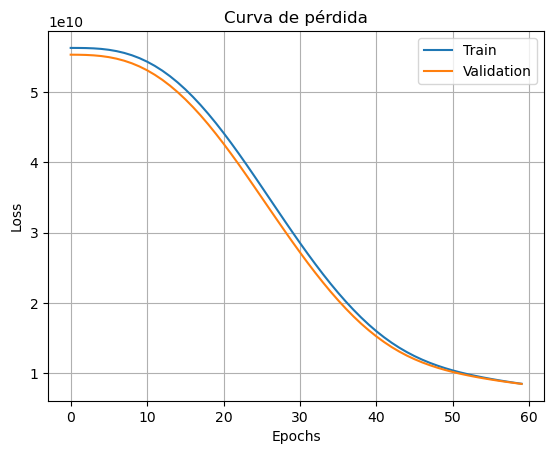

In [14]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Curva de pérdida")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

# EVALUACIÓN FINAL
La evaluación final se realiza cargando el mejor modelo guardado.
Se calculan métricas estándar de regresión para cuantificar el error medio y la capacidad explicativa del modelo.

In [15]:
model.load_state_dict(torch.load("best_model.pt"))

loss, y_pred, y_real = evaluate(model, test_loader)

mae = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
r2 = r2_score(y_real, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 66381.6875
RMSE: 91991.96069222571
R2: 0.3542076349258423


PREDICCIONES

In [16]:
resultados = pd.DataFrame({
    "Real": y_real.flatten(),
    "Predicho": y_pred.flatten()
})

resultados["Error"] = abs(resultados["Real"] - resultados["Predicho"])
resultados.head(10)

,Real,Predicho,Error
0,47700.0,43284.496094,4415.503906
1,45800.0,82282.367188,36482.367188
2,500001.0,173417.140625,326583.875000
3,218600.0,227180.281250,8580.281250
4,278000.0,180664.609375,97335.390625
5,158700.0,149960.093750,8739.906250
6,198200.0,270079.531250,71879.531250
7,157500.0,211545.703125,54045.703125
8,340000.0,165892.406250,174107.593750
9,446600.0,397049.656250,49550.343750


# Parte 2


# Lab PyTorch con Dataset APS

### Objetivo del laboratorio
Construir un modelo de red neuronal en PyTorch para predecir fallas del sistema APS, aplicando:
- carga y limpieza del dataset,
- preprocesamiento profesional,
- `Dataset` personalizado,
- `DataLoader`,
- entrenamiento por épocas,
- evaluación con métricas adecuadas,
- guardado de checkpoints.

In [17]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, recall_score, precision_score
import matplotlib.pyplot as plt

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo en uso:', device)

RANDOM_STATE = 42
BATCH_SIZE = 256
EPOCHS = 20
LR = 1e-3
CHECKPOINT_DIR = 'checkpoints_aps'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Dispositivo en uso: cpu


## 2. Configuración general

Aquí se define el dispositivo de trabajo.  
A diferencia del cuadernillo del ingeniero, donde se usaba `.cuda()` directamente, aquí se utiliza `device = torch.device(...)` para que el notebook sea más portable y profesional, funcionando tanto en CPU como en GPU.

In [19]:
RANDOM_STATE = 42
BATCH_SIZE = 256
EPOCHS = 20
LR = 1e-3
CHECKPOINT_DIR = "checkpoints_aps"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

## 3. Carga del dataset APS

El dataset APS no viene en formato limpio para entrenamiento directo.  
Contiene líneas informativas iniciales, por lo que se utiliza `skiprows=20` para leer correctamente la tabla.

Este dataset tiene **60000 registros** y **171 columnas** en total. La columna `class` representa la variable objetivo y el resto son variables predictoras.


In [20]:
df = pd.read_csv('aps_failure_training_set.csv', skiprows=20)
print('Dimensión del dataset:', df.shape)
df.head()


Dimensión del dataset: (60000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0


## 4. Exploración inicial

Antes de entrenar una red neuronal, es indispensable comprender la estructura de los datos.  
Aquí verificamos la distribución de clases y observamos un aspecto crítico: el dataset está **fuertemente desbalanceado**.

Esto significa que hay muchas más observaciones de la clase negativa que de la positiva.  
Por tanto, la métrica `accuracy` por sí sola no es suficiente para evaluar el modelo.

In [21]:
print(df['class'].value_counts())


class
neg    59000
pos     1000
Name: count, dtype: int64


## 5. Limpieza de datos
Primero convertimos esos valores a `NaN`, luego separamos variables predictoras y etiqueta.

In [22]:
df = df.replace('na', np.nan)

X = df.drop(columns=['class'])
y = df['class']

X = X.apply(pd.to_numeric, errors='coerce')
y = y.map({'neg': 0, 'pos': 1}).astype(np.int64)

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)
print('Distribución de clases codificadas:')
print(y.value_counts())


Shape de X: (60000, 170)
Shape de y: (60000,)
Distribución de clases codificadas:
class
0    59000
1     1000
Name: count, dtype: int64


## 6. División en entrenamiento y prueba

Se divide el dataset en **80% entrenamiento** y **20% prueba**.  
Se usa `stratify=y` para conservar la misma proporción de clases en ambos subconjuntos.

Esto es especialmente importante en datasets desbalanceados, porque evita que una de las particiones quede con muy pocos ejemplos positivos.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)


Train: (48000, 170) (48000,)
Test : (12000, 170) (12000,)


## 7. Imputación de valores faltantes

Como el dataset tiene muchos valores faltantes, no se puede entrenar directamente.  
Se utiliza `SimpleImputer(strategy='median')` para reemplazar los valores faltantes por la mediana de cada atributo.

La mediana es una decisión adecuada porque es robusta frente a valores extremos y outliers.

Además, el ajuste del imputador se realiza **solo con el conjunto de entrenamiento** para evitar fuga de información.


In [24]:
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print('Valores faltantes en train:', np.isnan(X_train).sum())
print('Valores faltantes en test :', np.isnan(X_test).sum())


Valores faltantes en train: 0
Valores faltantes en test : 0


## 8. Escalado de variables

Las redes neuronales se benefician de variables en escalas comparables.  
Por ello se aplica `StandardScaler`, que centra cada variable en media 0 y desviación estándar 1.



In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)


## 9. Construcción del Dataset personalizado

crear una clase heredada de `torch.utils.data.Dataset`.  
La clase define tres métodos esenciales:

- `__init__`: almacena los datos
- `__len__`: devuelve el número de ejemplos
- `__getitem__`: devuelve una muestra específica

La diferencia profesional es que aquí los tensores se almacenan inicialmente en CPU, y recién dentro del entrenamiento se mueven a `device` por lote.


In [26]:
class APSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = APSDataset(X_train, y_train)
test_dataset = APSDataset(X_test, y_test)

print('Tamaño train_dataset:', len(train_dataset))
print('Tamaño test_dataset :', len(test_dataset))


Tamaño train_dataset: 48000
Tamaño test_dataset : 12000


## 10. DataLoader

El `DataLoader` automatiza la construcción de batches y facilita el entrenamiento en PyTorch.  
En entrenamiento se usa `shuffle=True` para mezclar los datos al inicio de cada época, mientras que en prueba se deja `shuffle=False`.



In [27]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print('Shape x_batch:', x_batch.shape)
print('Shape y_batch:', y_batch.shape)


Shape x_batch: torch.Size([256, 170])
Shape y_batch: torch.Size([256])


## 11. Definición del modelo

La arquitectura del modelo también se adapta al problema.  
  
Aquí se construye una red para **clasificación binaria tabular**, con:

- capa de entrada según el número de features,
- capas ocultas densas,
- activación ReLU,
- dropout para reducir sobreajuste,
- una sola neurona de salida.

La salida única representa el logit asociado a la clase positiva.


In [28]:
input_dim = X_train.shape[1]

model = torch.nn.Sequential(
    torch.nn.Linear(input_dim, 128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(64, 1)
).to(device)

model


Sequential(
  (0): Linear(in_features=170, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=64, out_features=1, bias=True)
)

## 12. Función de pérdida y optimizador

Como el problema es binario, se usa `BCEWithLogitsLoss`.  
Esta función combina internamente una sigmoide con la entropía cruzada binaria, ofreciendo mayor estabilidad numérica.

Además, como el dataset está desbalanceado, se calcula `pos_weight` para dar mayor importancia a la clase positiva.




In [29]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print('neg_count:', neg_count)
print('pos_count:', pos_count)
print('pos_weight:', pos_weight.item())


neg_count: 47200
pos_count: 800
pos_weight: 59.0


## 13. Función de evaluación

Se define una función para evaluar el modelo sobre cualquier `DataLoader`.  
La evaluación calcula:

- `accuracy`
- `precision`
- `recall`
- `F1-score`
- matriz de confusión

En un dataset desbalanceado, `recall` y `F1-score` son especialmente importantes porque permiten medir mejor el desempeño sobre la clase minoritaria.


In [30]:
def evaluate_model(model, dataloader, threshold=0.5):
    model.eval()
    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch).squeeze(1)
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).long()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    acc = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, zero_division=0)
    recall = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    cm = confusion_matrix(all_targets, all_preds)

    return acc, precision, recall, f1, cm, all_targets, all_preds, all_probs


## 14. Entrenamiento del modelo

Aquí se aplica el ciclo clásico de entrenamiento de PyTorch:

1. `forward`
2. cálculo de pérdida
3. `zero_grad()`
4. `backward()`
5. `step()`

Además, en cada época se guardará un checkpoint con el estado del modelo y del optimizador.



In [31]:
history_loss = []
history_f1 = []
history_recall = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_losses = []

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch).squeeze(1)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = np.mean(epoch_losses)
    history_loss.append(avg_loss)

    acc, precision, recall, f1, cm, _, _, _ = evaluate_model(model, test_loader)
    history_f1.append(f1)
    history_recall.append(recall)

    print(f'Epoch {epoch:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}')

    checkpoint_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch}.pt')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss
    }, checkpoint_path)


Epoch 01/20 | Loss: 0.4943 | Acc: 0.9316 | Precision: 0.1941 | Recall: 0.9850 | F1: 0.3243
Epoch 02/20 | Loss: 0.3078 | Acc: 0.9587 | Precision: 0.2830 | Recall: 0.9650 | F1: 0.4376
Epoch 03/20 | Loss: 0.2630 | Acc: 0.9600 | Precision: 0.2885 | Recall: 0.9550 | F1: 0.4432
Epoch 04/20 | Loss: 0.2493 | Acc: 0.9692 | Precision: 0.3461 | Recall: 0.9500 | F1: 0.5073
Epoch 05/20 | Loss: 0.2294 | Acc: 0.9621 | Precision: 0.3005 | Recall: 0.9600 | F1: 0.4577
Epoch 06/20 | Loss: 0.2278 | Acc: 0.9609 | Precision: 0.2947 | Recall: 0.9650 | F1: 0.4515
Epoch 07/20 | Loss: 0.2208 | Acc: 0.9568 | Precision: 0.2748 | Recall: 0.9700 | F1: 0.4283
Epoch 08/20 | Loss: 0.2238 | Acc: 0.9691 | Precision: 0.3448 | Recall: 0.9500 | F1: 0.5060
Epoch 09/20 | Loss: 0.1923 | Acc: 0.9648 | Precision: 0.3168 | Recall: 0.9600 | F1: 0.4764
Epoch 10/20 | Loss: 0.2129 | Acc: 0.9598 | Precision: 0.2902 | Recall: 0.9750 | F1: 0.4472
Epoch 11/20 | Loss: 0.2048 | Acc: 0.9619 | Precision: 0.3008 | Recall: 0.9700 | F1: 0.4592

## 15. Evaluación final

Una vez entrenado el modelo, se calculan las métricas finales sobre el conjunto de prueba.  
La matriz de confusión permite observar cuántos casos positivos y negativos fueron correctamente clasificados, y el reporte de clasificación resume el desempeño por clase.


In [32]:
acc, precision, recall, f1, cm, y_true, y_pred, y_prob = evaluate_model(model, test_loader)

print('=== RESULTADOS FINALES ===')
print('Accuracy :', acc)
print('Precision:', precision)
print('Recall   :', recall)
print('F1-score :', f1)
print('\nMatriz de confusión:')
print(cm)
print('\nReporte de clasificación:')
print(classification_report(y_true, y_pred, digits=4))


=== RESULTADOS FINALES ===
Accuracy : 0.9659166666666666
Precision: 0.32377740303541314
Recall   : 0.96
F1-score : 0.4842370744010088

Matriz de confusión:
[[11399   401]
 [    8   192]]

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0     0.9993    0.9660    0.9824     11800
         1.0     0.3238    0.9600    0.4842       200

    accuracy                         0.9659     12000
   macro avg     0.6615    0.9630    0.7333     12000
weighted avg     0.9880    0.9659    0.9741     12000



## 16. Visualización de la pérdida

Se grafica la pérdida promedio por época para observar si el entrenamiento converge.  
Una disminución progresiva de la pérdida sugiere que el modelo está aprendiendo patrones en los datos.


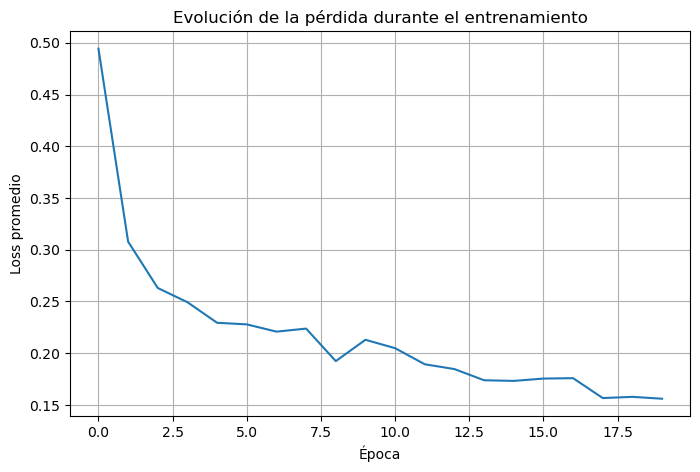

In [33]:
plt.figure(figsize=(8,5))
plt.plot(history_loss)
plt.xlabel('Época')
plt.ylabel('Loss promedio')
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.grid(True)
plt.show()


## 17. Visualización de métricas

También es útil observar la evolución de métricas relevantes como `F1-score` y `Recall`.  
En un problema desbalanceado, estas curvas permiten interpretar si el modelo está mejorando realmente en la detección de la clase positiva.


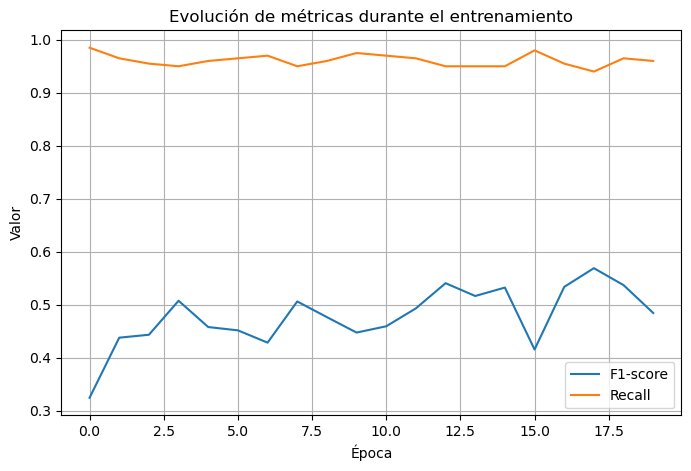

In [34]:
plt.figure(figsize=(8,5))
plt.plot(history_f1, label='F1-score')
plt.plot(history_recall, label='Recall')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.title('Evolución de métricas durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()


## 18. Carga de un checkpoint

Una de las ventajas del enfoque del ingeniero es el uso de checkpoints.  
Esto permite recuperar el entrenamiento sin empezar desde cero o reutilizar un modelo ya entrenado.

A continuación se muestra cómo cargar el último checkpoint guardado.


In [35]:
last_checkpoint = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{EPOCHS}.pt')
checkpoint = torch.load(last_checkpoint, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

print('Checkpoint cargado desde:', last_checkpoint)
print('Época almacenada:', checkpoint['epoch'])
print('Loss almacenada:', checkpoint['loss'])


Checkpoint cargado desde: checkpoints_aps\checkpoint_epoch_20.pt
Época almacenada: 20
Loss almacenada: 0.15598197282351395


## 19. Conclusión

En este laboratorio se reutilizó correctamente la lógica del cuadernillo del ingeniero, pero adaptándola a un problema real con un dataset tabular complejo.  
La adaptación incluyó limpieza de datos, imputación de faltantes, escalado, tratamiento del desbalance, definición de un `Dataset` personalizado, uso de `DataLoader`, entrenamiento de una red neuronal y almacenamiento de checkpoints.

Desde un punto de vista profesional, esto demuestra que no solo se reutilizó código, sino que se comprendió la arquitectura de PyTorch y se modificó de acuerdo con la naturaleza del nuevo problema.
